## ⚙️ Environment Requirements

To ensure compatibility and avoid serialization issues when saving and loading the `RandomForestClassifier` model, this notebook uses the following library versions:

- **scikit-learn**: `1.2.2`  
- **numpy**: `1.23.5`

These versions match Kaggle's default environment, ensuring that the trained model (`random_forest_model.pkl`) can be loaded successfully during submission.


In [1]:
import sklearn
print(sklearn.__version__)

import numpy
print(numpy.__version__)

1.2.2
1.23.5


In this notebook, I trained a Random Forest classifier using features derived from precomputed log-Mel spectrograms stored as .npz files. These Mel features were extracted from preprocessed audio chunks (already trimmed for human speech in prior steps).

Key Steps:
- Load metadata from train.csv and map each Mel file to its primary label.
- Extract statistical features from each Mel spectrogram:
    - Mean and standard deviation across Mel bands (64 + 64 = 128 features per sample).
- Label encode species names for model compatibility.
- Filter out rare classes (with fewer than 2 samples).
- Train-test split using stratified sampling to preserve class distribution.
- Train a Random Forest classifier with class balancing to handle label imbalance.
- Evaluate the model using accuracy and a classification report.
- Export the trained model and label encoder for later inference.


In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import joblib

# === CONFIG ===
mel_dir = "processed/feature"
csv_path = "data/train.csv"
label_encoder_path = "label_encoder.pkl"

# === Step 1: Load metadata and label map ===
df = pd.read_csv(csv_path)
label_map_raw = {
    row['filename'].split('/')[-1].split('.')[0]: row['primary_label']
    for _, row in df.iterrows()
}

le = LabelEncoder()
le.fit(list(label_map_raw.values()))
label_map = {k: le.transform([v])[0] for k, v in label_map_raw.items()}

# Save label encoder
joblib.dump(le, label_encoder_path)

# === Step 2: Extract features from mel spectrograms ===
X_raw, y_raw = [], []

for fname in tqdm(sorted(os.listdir(mel_dir))):
    if not fname.endswith('_mel.npz'):
        continue

    clip_id = fname.rsplit('_', 2)[0]
    if clip_id not in label_map:
        continue

    data = np.load(os.path.join(mel_dir, fname))
    mel = data['mel']  # shape: (64, time)

    if mel.ndim != 2 or mel.shape[0] != 64:
        continue  # skip malformed input

    mean = mel.mean(axis=1)  # shape: (64,)
    std = mel.std(axis=1)    # shape: (64,)
    feature = np.concatenate([mean, std])  # shape: (128,)

    X_raw.append(feature)
    y_raw.append(label_map[clip_id])

# Convert to arrays
X = np.array(X_raw)
y = np.array(y_raw)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)
print("Sample feature (first):", X[0][:5])


unique_labels, counts = np.unique(y, return_counts=True)

print(f"Total number of unique classes: {len(unique_labels)}\n")

for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} samples")



100%|██████████| 129273/129273 [02:38<00:00, 815.24it/s] 


Feature shape: (129273, 128)
Labels shape: (129273,)
Sample feature (first): [-34.412647 -23.971998 -18.916466 -17.687073 -18.924423]
Total number of unique classes: 206

Label 0: 17 samples
Label 1: 46 samples
Label 2: 6 samples
Label 3: 6 samples
Label 4: 36 samples
Label 5: 24 samples
Label 6: 202 samples
Label 7: 38 samples
Label 8: 77 samples
Label 9: 6 samples
Label 10: 34 samples
Label 11: 2 samples
Label 12: 182 samples
Label 13: 69 samples
Label 14: 190 samples
Label 15: 110 samples
Label 16: 18 samples
Label 17: 14 samples
Label 18: 71 samples
Label 19: 523 samples
Label 20: 25 samples
Label 21: 35 samples
Label 22: 64 samples
Label 23: 3 samples
Label 24: 3 samples
Label 25: 22 samples
Label 26: 9 samples
Label 27: 35 samples
Label 28: 9 samples
Label 29: 324 samples
Label 30: 406 samples
Label 31: 142 samples
Label 32: 4 samples
Label 33: 23 samples
Label 34: 430 samples
Label 35: 6 samples
Label 36: 135 samples
Label 37: 8 samples
Label 38: 85 samples
Label 39: 67 samples


In [ ]:
# === BLOCK 2: Hyperparameter Validation (Safe Setup with Stratify) ===
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# First split: train + val and test (with stratify)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Second split: train and val (again with stratify)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42  # ~15% of total data
)

# Reduced param grid for quick search
param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Use RandomizedSearchCV for safe tuning
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=4,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

# Validate with the selected model on validation set
best_model = random_search.best_estimator_
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_accuracy)

# Save best parameters for future use
best_params = random_search.best_params_


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Users/istiak/Desktop/birdCLEF2025/birdclef_env/lib/python3.10/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best Parameters: {'min_samples_split': 2, 'max_depth': None}
Validation Accuracy: 0.5365300335137922


: 

In [ ]:
from sklearn.model_selection import train_test_split

# Recreate the original splits
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Best parameters from RandomizedSearchCV
best_params = {'min_samples_split': 2, 'max_depth': None}

# Train the final model on full training data (train + val)
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42
)
final_model.fit(X_temp, y_temp)

# Evaluate on test set
y_test_pred = final_model.predict(X_test)

print("\nFinal Test Performance:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(y_test, y_test_pred))

# Save model to disk
joblib.dump(final_model, "random_forest_final_model.pkl", compress=1)


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Predict probabilities
y_test_proba = final_model.predict_proba(X_test)

# One-hot encode true labels
classes = final_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

# Filter out classes with no positive samples in y_test
valid_classes = y_test_bin.sum(axis=0) > 0
y_test_bin_valid = y_test_bin[:, valid_classes]
y_test_proba_valid = y_test_proba[:, valid_classes]

# Compute macro-average ROC-AUC only on valid classes
roc_auc = roc_auc_score(y_test_bin_valid, y_test_proba_valid, average='macro')
print("Macro-Averaged ROC-AUC Score (filtered):", roc_auc)


Macro-Averaged ROC-AUC Score (filtered): 0.8910397614171273


In [ ]:
report_text ="""
Final Test Performance:
Accuracy: 0.5521633747614872
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.60      0.43      0.50         7
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       1.00      0.60      0.75         5
           5       1.00      0.75      0.86         4
           6       0.88      0.93      0.90        30
           7       0.50      0.33      0.40         6
           8       0.50      0.92      0.65        12
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         5
          12       0.69      0.33      0.45        27
          13       1.00      0.30      0.46        10
          14       0.85      0.39      0.54        28
          15       0.50      0.25      0.33        16
          16       0.00      0.00      0.00         3
          17       1.00      0.50      0.67         2
          18       1.00      0.64      0.78        11
          19       0.66      0.42      0.52        78
          20       1.00      0.25      0.40         4
          21       1.00      0.20      0.33         5
          22       1.00      0.20      0.33        10
          23       0.00      0.00      0.00         0
          25       0.75      1.00      0.86         3
          26       0.00      0.00      0.00         1
          27       1.00      0.40      0.57         5
          28       0.00      0.00      0.00         1
          29       0.88      0.78      0.83        49
          30       0.85      0.72      0.78        61
          31       0.86      0.29      0.43        21
          32       0.00      0.00      0.00         1
          33       0.50      0.33      0.40         3
          34       0.83      0.58      0.68        65
          35       0.00      0.00      0.00         1
          36       0.93      0.65      0.76        20
          37       0.00      0.00      0.00         1
          38       0.82      0.69      0.75        13
          39       1.00      0.90      0.95        10
          40       1.00      0.33      0.50         3
          41       1.00      0.56      0.71         9
          42       1.00      0.25      0.40         4
          43       1.00      0.20      0.33        10
          44       0.00      0.00      0.00         1
          45       0.62      0.40      0.49        25
          46       1.00      0.33      0.50         3
          47       0.00      0.00      0.00         5
          48       0.00      0.00      0.00         0
          49       1.00      1.00      1.00         1
          50       0.00      0.00      0.00         2
          51       1.00      1.00      1.00         1
          52       1.00      1.00      1.00         1
          53       1.00      0.63      0.77        19
          54       0.83      1.00      0.91         5
          55       0.40      0.62      0.48        13
          56       0.00      0.00      0.00         2
          58       0.00      0.00      0.00         1
          59       0.50      0.40      0.44         5
          60       0.62      0.19      0.29        26
          61       0.57      0.56      0.56       209
          62       0.67      0.17      0.27        12
          63       0.75      0.30      0.43        40
          64       0.80      0.61      0.69       162
          65       0.80      0.40      0.53        10
          66       0.49      0.83      0.62       462
          67       0.45      0.36      0.40        94
          68       0.63      0.43      0.51       162
          69       0.65      0.32      0.43        53
          70       0.62      0.56      0.59       126
          71       0.60      0.74      0.66       232
          72       0.65      0.73      0.69       288
          73       0.78      0.61      0.68       125
          74       0.94      0.30      0.45        57
          75       0.70      0.25      0.37        28
          76       0.67      0.49      0.57       116
          77       1.00      0.25      0.40        16
          78       0.54      0.35      0.43        82
          79       0.73      0.41      0.53        46
          80       0.43      0.50      0.46       326
          81       0.50      0.13      0.21        15
          82       0.86      0.40      0.55        45
          83       1.00      0.19      0.32        16
          84       0.55      0.52      0.54       267
          85       0.93      0.60      0.73        47
          86       0.50      0.34      0.41       169
          87       0.66      0.51      0.58       221
          88       0.74      0.38      0.50        45
          89       0.69      0.51      0.58        97
          90       0.63      0.70      0.66       230
          91       0.62      0.43      0.50        87
          92       0.59      0.27      0.37        37
          93       1.00      0.79      0.88        14
          94       0.72      0.53      0.61       131
          95       0.81      0.35      0.49        37
          96       0.65      0.65      0.65       164
          97       0.45      0.80      0.57       614
          98       0.84      0.68      0.75       252
          99       0.49      0.34      0.40       101
         100       0.83      0.37      0.51        27
         101       0.71      0.62      0.66       133
         102       0.73      0.58      0.64        33
         103       0.89      0.58      0.70        59
         104       0.59      0.42      0.49       180
         105       0.74      0.40      0.52        58
         106       1.00      0.29      0.45        51
         107       0.78      0.48      0.59       117
         108       0.83      0.27      0.41        55
         109       0.77      0.33      0.47        60
         110       0.87      0.59      0.70       110
         111       0.38      0.50      0.43       118
         112       0.81      0.43      0.56        61
         113       0.26      0.62      0.37       548
         114       0.91      0.64      0.75        45
         115       0.90      0.40      0.55        48
         116       0.74      0.46      0.56        68
         117       1.00      0.29      0.45        17
         118       0.74      0.25      0.38        67
         119       0.61      0.78      0.68       248
         120       0.83      0.22      0.34        23
         121       0.57      0.79      0.66       383
         122       0.76      0.37      0.50        51
         123       0.55      0.47      0.50       215
         124       0.66      0.64      0.65       270
         125       0.86      0.38      0.53        65
         126       0.83      0.40      0.54        47
         127       0.80      0.27      0.40        15
         128       0.86      0.50      0.63        24
         129       0.59      0.45      0.51       114
         130       0.56      0.22      0.31        23
         131       0.74      0.48      0.58       179
         132       0.83      0.26      0.40        92
         133       0.82      0.36      0.50        25
         134       0.62      0.46      0.53       256
         135       1.00      0.11      0.20         9
         136       0.82      0.44      0.58       135
         137       1.00      0.50      0.67         4
         138       0.88      0.25      0.39        28
         139       0.83      0.45      0.58        78
         140       0.78      0.31      0.44        45
         141       0.93      0.46      0.62        56
         142       0.64      0.23      0.33        31
         143       0.73      0.29      0.42        92
         144       0.29      0.62      0.40       584
         145       0.89      0.80      0.84        30
         146       1.00      0.44      0.62        18
         147       0.83      0.53      0.65       117
         148       0.85      0.39      0.53        59
         149       0.88      0.55      0.68        78
         150       0.79      0.41      0.54        73
         151       0.75      0.35      0.48       142
         152       0.97      0.61      0.75        56
         153       0.72      0.33      0.45       124
         154       1.00      0.22      0.36         9
         155       0.50      0.61      0.55       319
         156       1.00      0.33      0.50         6
         157       0.57      0.17      0.26        24
         158       0.67      0.37      0.48        75
         159       1.00      0.50      0.67        10
         160       0.90      0.35      0.51        54
         161       0.61      0.34      0.43       136
         162       0.71      0.29      0.41        42
         163       0.50      0.35      0.41       272
         164       0.44      0.52      0.48       377
         165       0.70      0.30      0.42        99
         166       0.45      0.35      0.40       175
         167       0.80      0.36      0.50        22
         168       0.83      0.84      0.83       298
         169       0.88      0.44      0.59        50
         170       0.76      0.42      0.54        53
         171       0.67      0.55      0.61       137
         172       0.65      0.58      0.61       279
         173       0.64      0.43      0.52       256
         174       0.51      0.38      0.43        53
         175       0.85      0.60      0.71       162
         176       0.89      0.35      0.50        23
         177       0.83      0.39      0.53       127
         178       0.83      0.64      0.72        91
         179       0.49      0.68      0.57       500
         180       0.61      0.57      0.59       327
         181       0.61      0.78      0.69       440
         182       1.00      0.11      0.20         9
         183       1.00      0.13      0.23        39
         184       0.58      0.15      0.24        46
         185       0.54      0.55      0.55       358
         186       0.78      0.37      0.50        84
         187       0.56      0.57      0.56       246
         188       0.62      0.44      0.51        98
         189       0.77      0.42      0.54        24
         190       0.49      0.75      0.59       562
         191       0.96      0.45      0.61        49
         192       0.89      0.47      0.62        34
         193       0.85      0.50      0.63        22
         194       0.80      0.32      0.46        74
         195       0.71      0.41      0.52       131
         196       0.71      0.46      0.56       129
         197       0.68      0.44      0.53       153
         198       0.61      0.57      0.59       190
         199       0.67      0.13      0.22        45
         200       0.91      0.57      0.70        56
         201       0.69      0.31      0.42       121
         202       0.83      0.48      0.61        42
         203       0.52      0.59      0.55       414
         204       0.36      0.67      0.47       403
         205       0.80      0.41      0.54       107

    accuracy                           0.55     19391
   macro avg       0.70      0.44      0.51     19391
weighted avg       0.62      0.55      0.55     19391
"""
import pandas as pd
import re
from io import StringIO
import joblib

# Load LabelEncoder
le = joblib.load("label_encoder.pkl")

# Raw classification report string


# Extract class-wise lines only
lines = [line.strip() for line in report_text.strip().split('\n') if re.match(r'^\d+', line.strip())]

# Parse lines into rows
rows = []
for line in lines:
    parts = re.split(r'\s+', line.strip())
    if len(parts) == 5:
        label, precision, recall, f1, support = parts
        rows.append({
            "label": int(label),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "support": support
        })

# Create DataFrame
df = pd.DataFrame(rows)

# Add species name using LabelEncoder
df["species"] = df["label"].apply(lambda x: le.inverse_transform([x])[0])

# Sort and select
top_5 = df.sort_values(by="f1", ascending=False).head(5)
bottom_5 = df[df["f1"] >= 0].sort_values(by="f1", ascending=True).head(5)

# Display
print("\nTop 5 Performing Classes:")
print(top_5[["label", "species", "f1", "support"]])

print("\nBottom 5 Performing Classes:")
print(bottom_5[["label", "species", "f1", "support"]])



Top 5 Performing Classes:
    label  species   f1 support
50     52    67082  1.0       1
3       3   126247  1.0       1
49     51    66893  1.0       1
47     49    66531  1.0       1
9       9  1564122  1.0       1

Bottom 5 Performing Classes:
    label  species   f1 support
0       0  1139490  0.0       3
22     23    42087  0.0       0
30     32   523060  0.0       1
33     35   548639  0.0       1
35     37   555142  0.0       1


In [ ]:
import pandas as pd
import re
from io import StringIO
import joblib

# Load label encoder to decode class labels back to species
le = joblib.load("label_encoder.pkl")

# === Assuming report_text is already defined ===
# Extract lines that represent class rows
lines = [line for line in report_text.strip().split('\n') if re.match(r'^\s*\d+', line)]

# Format as tabular data
formatted = "\n".join(["label precision recall f1 support"] + lines)

# Load into DataFrame
df = pd.read_csv(StringIO(formatted), sep='\s+')

# Ensure support is numeric
df['support'] = pd.to_numeric(df['support'], errors='coerce')

# Filter for F1 = 0.0 only
f1_zero_df = df[df['f1'] == 0.0].sort_values(by='support', ascending=False)

# Add species name column using LabelEncoder inverse transform
f1_zero_df['species'] = f1_zero_df['label'].apply(lambda x: le.inverse_transform([int(x)])[0])

# Display result
print(" Classes with F1 Score = 0.0 (including species):")
print(f1_zero_df[['label','species',   'f1', 'support']])

# Sort by support descending and get top 5
top_support_df = df.sort_values(by='support', ascending=False).head(5)

# Decode label to species using label encoder
top_support_df['species'] = top_support_df['label'].apply(lambda x: le.inverse_transform([int(x)])[0])

# Display result
print("Top 5 Classes with Highest Support (with F1 Scores):")
print(top_support_df[['label', 'species', 'f1', 'support']])



 Classes with F1 Score = 0.0 (including species):
    label  species   f1  support
45     47    65962  0.0        5
0       0  1139490  0.0        3
15     16    24272  0.0        3
48     50    66578  0.0        2
54     56   787625  0.0        2
2       2  1194042  0.0        1
24     26    47067  0.0        1
26     28   476538  0.0        1
30     32   523060  0.0        1
33     35   548639  0.0        1
35     37   555142  0.0        1
42     44    65419  0.0        1
55     58   868458  0.0        1
22     23    42087  0.0        0
46     48    66016  0.0        0
Top 5 Classes with Highest Support (with F1 Scores):
     label species    f1  support
94      97  compau  0.57      614
141    144  roahaw  0.40      584
187    190  whtdov  0.59      562
110    113  grekis  0.37      548
176    179  trokin  0.57      500


In [ ]:
import pandas as pd
import re
from io import StringIO


# Step 1: Filter lines with class metrics (starting with digit)
lines = [line for line in report_text.strip().split('\n') if re.match(r'^\s*\d+', line)]

# Step 2: Construct table-like input
formatted = "\n".join(["label precision recall f1 support"] + lines)

# Step 3: Read into DataFrame
df = pd.read_csv(StringIO(formatted), sep='\s+')

# Convert support column to numeric
df['support'] = pd.to_numeric(df['support'], errors='coerce')

# Filter out rows with zero or missing support
non_zero_support = df[df['support'] > 0]

# Get top 10 classes with highest support
top_10_support = non_zero_support.sort_values(by='support', ascending=False).head(10)

# Get bottom 10 classes with lowest (non-zero) support
bottom_10_support = non_zero_support.sort_values(by='support', ascending=True).head(10)

# Print results
print("🔝 Top 10 Classes by Support:")
print(top_10_support[['label', 'f1', 'support']])

print("\n🔻 Bottom 10 Classes by Support (Non-zero):")
print(bottom_10_support[['label', 'f1', 'support']])


🔝 Top 10 Classes by Support:
     label    f1  support
94      97  0.57      614
141    144  0.40      584
187    190  0.59      562
110    113  0.37      548
176    179  0.57      500
63      66  0.62      462
178    181  0.69      440
200    203  0.55      414
201    204  0.47      403
118    121  0.66      383

🔻 Bottom 10 Classes by Support (Non-zero):
    label   f1  support
47     49  1.0        1
24     26  0.0        1
50     52  1.0        1
26     28  0.0        1
30     32  0.0        1
9       9  1.0        1
55     58  0.0        1
49     51  1.0        1
35     37  0.0        1
42     44  0.0        1


In [ ]:
import pandas as pd
import joblib

# Load CSV and label encoder
df = pd.read_csv("data/train.csv")
le = joblib.load("label_encoder.pkl")

# Example: target encoded label (e.g., 5)
target_label_int = 48
original_label = le.inverse_transform([target_label_int])[0]

# Find filenames with that label
matching_rows = df[df['primary_label'] == original_label]

print(f"Original label for {target_label_int} is: {original_label}")
print("Matching filenames:")
print(matching_rows['filename'].values)


Original label for 48 is: 66016
Matching filenames:
['66016/XC893981.ogg' '66016/iNat14973.ogg']


In [8]:
# === Naive Class-Prior (Constant) Baseline — for .npz files ===
import os, re, numpy as np, pandas as pd, joblib
from sklearn.preprocessing import LabelEncoder

# ---------- CONFIG ----------
BASE_DIR = "/Users/istiak/Desktop/birdCLEF2025"
MEL_DIR   = os.path.join(BASE_DIR, "processed/feature")      # folder with your *.npz
CSV_PATH  = os.path.join(BASE_DIR, "data/train.csv")         # your train.csv
LE_PATH   = os.path.join(BASE_DIR, "label_encoder.pkl")      # saved/loaded label encoder
SEG_EXT   = ".npz"                                           # <-- npz
EVAL_MODE = "segment"    # "segment" -> scan *.npz ;  "record" -> use rows in train.csv
SEED = 42
TRAIN_FRAC = 0.80
# ----------------------------

def norm_id(s: str) -> str:
    """Normalize an ID: lowercase, strip extension, keep only [a-z0-9]."""
    stem = os.path.splitext(os.path.basename(str(s)))[0].lower()
    # common suffix bits to drop, adjust if needed
    for tail in ("_mel", "_spec", "_melspec", "-mel", "-spec"):
        if stem.endswith(tail): stem = stem[: -len(tail)]
    return re.sub(r"[^a-z0-9]+", "", stem)

def extract_candidates_from_stem(stem: str):
    """
    Return candidate clip IDs (not normalized yet) from a file stem.
    Handles patterns like:
      XC12345_000_005_mel.npz -> XC12345
      XC12345_000_005.npz     -> XC12345
      XC12345.npz             -> XC12345
    """
    cands = [stem]
    parts = stem.split("_")
    if len(parts) >= 3:
        cands.append("_".join(parts[:-2]))      # drop last 2 tokens (e.g., start_end)
    if len(parts) >= 4:
        cands.append("_".join(parts[:-3]))      # drop last 3 tokens if suffix is longer
    cands.append(parts[0])                      # first token only
    m = re.search(r"(xc\d+)", stem.lower())     # try explicit XC pattern anywhere
    if m:
        cands.append(m.group(1).upper())
        cands.append(m.group(1).lower())
    # de-dup preserve order
    seen, out = set(), []
    for c in cands:
        if c not in seen:
            out.append(c); seen.add(c)
    return out

def build_clip_to_label(csv_path: str):
    df = pd.read_csv(csv_path)
    if "primary_label" not in df.columns:
        raise RuntimeError("Expected 'primary_label' in train.csv")
    if "filename" in df.columns:
        csv_ids_raw = df["filename"].astype(str).apply(
            lambda p: os.path.splitext(os.path.basename(p))[0]
        ).tolist()
    elif "clip_id" in df.columns:
        csv_ids_raw = df["clip_id"].astype(str).tolist()
    else:
        raise RuntimeError(f"Expected 'filename' or 'clip_id' in train.csv; found: {list(df.columns)}")
    csv_ids_norm = [norm_id(x) for x in csv_ids_raw]
    clip_to_label = {}
    for cidn, lab in zip(csv_ids_norm, df["primary_label"].astype(str).tolist()):
        clip_to_label[cidn] = lab
    return clip_to_label

def labels_record_level(csv_path: str):
    df = pd.read_csv(csv_path)
    return df["primary_label"].astype(str).tolist()

def labels_segment_level(seg_dir: str, csv_path: str, ext: str):
    if not os.path.isdir(seg_dir):
        raise RuntimeError(f"Feature directory not found: {seg_dir}")
    clip_to_label = build_clip_to_label(csv_path)
    id_set = set(clip_to_label.keys())

    labels, total, matched = [], 0, 0
    debug_samples = []
    # walk in case files are in subfolders
    all_files = []
    for root, _, files in os.walk(seg_dir):
        for f in files:
            if f.endswith(ext):
                all_files.append(os.path.join(root, f))
    all_files.sort()
    print(f"Found {len(all_files)} files with '{ext}' under {seg_dir}")

    for path in all_files:
        total += 1
        fname = os.path.basename(path)
        stem = os.path.splitext(fname)[0]
        found_label = None
        for cand in extract_candidates_from_stem(stem):
            cand_norm = norm_id(cand)
            if cand_norm in id_set:
                found_label = clip_to_label[cand_norm]
                break
        if found_label is not None:
            labels.append(found_label)
            matched += 1
            if len(debug_samples) < 6:
                debug_samples.append((fname, stem, cand, found_label))
        elif len(debug_samples) < 6:
            debug_samples.append((fname, stem, "NO_MATCH", None))

    print(f"Segment mapping: total={total}, matched={matched} ({matched/max(1,total):.1%})")
    print("Diagnostics (few examples): file | stem | chosen_candidate | label")
    for row in debug_samples:
        print("  ", " | ".join([str(x) for x in row]))

    if matched == 0:
        raise RuntimeError(
            "No segment files matched CSV labels.\n"
            "Use diagnostics and tweak extract_candidates_from_stem()/norm_id()."
        )
    return labels

# --------- MAIN ----------
if EVAL_MODE == "record":
    y_raw = labels_record_level(CSV_PATH)
else:
    y_raw = labels_segment_level(MEL_DIR, CSV_PATH, SEG_EXT)

if len(y_raw) < 2:
    raise RuntimeError("Not enough labels to evaluate.")

# LabelEncoder (load or fit for full class list)
if os.path.exists(LE_PATH):
    le = joblib.load(LE_PATH)
    # ensure coverage
    if not set(y_raw).issubset(set(le.classes_)):
        all_csv = pd.read_csv(CSV_PATH)["primary_label"].astype(str).tolist()
        le = LabelEncoder().fit(all_csv)
        joblib.dump(le, LE_PATH)
else:
    all_csv = pd.read_csv(CSV_PATH)["primary_label"].astype(str).tolist()
    le = LabelEncoder().fit(all_csv)
    os.makedirs(os.path.dirname(LE_PATH), exist_ok=True)
    joblib.dump(le, LE_PATH)

classes = list(le.classes_)
C = len(classes)
y_all = le.transform(y_raw)
print(f"Total examples: {len(y_all)} | Classes: {C}")

# Split (80/20)
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(y_all))
cut = int(TRAIN_FRAC * len(perm))
y_train = y_all[perm[:cut]]
y_test  = y_all[perm[cut:]]

# Priors from TRAIN ONLY
counts = np.bincount(y_train, minlength=C)
priors = counts / counts.sum()

# Predictions (constant majority for accuracy; priors are your probability vector)
maj = int(np.argmax(priors))
y_pred = np.full_like(y_test, maj)
acc = (y_pred == y_test).mean()

print("\n=== Naive Class-Prior Baseline ===")
print(f"Majority class: {classes[maj]} | prior = {priors[maj]:.4f}")
print(f"Hold-out accuracy: {acc:.4f} (split {TRAIN_FRAC:.0%}/{1-TRAIN_FRAC:.0%}, seed={SEED})")

# Save priors + classes (optional, for later use)
np.savez(os.path.join(BASE_DIR, "class_prior_baseline.npz"),
         priors=priors, classes=np.array(classes, dtype=object))
print("Saved:", os.path.join(BASE_DIR, "class_prior_baseline.npz"))


Found 129273 files with '.npz' under /Users/istiak/Desktop/birdCLEF2025/processed/feature
Segment mapping: total=129273, matched=129273 (100.0%)
Diagnostics (few examples): file | stem | chosen_candidate | label
   CSA03598_10_mel.npz | CSA03598_10_mel | CSA03598 | 48124
   CSA03598_15_mel.npz | CSA03598_15_mel | CSA03598 | 48124
   CSA03598_20_mel.npz | CSA03598_20_mel | CSA03598 | 48124
   CSA03598_25_mel.npz | CSA03598_25_mel | CSA03598 | 48124
   CSA03598_30_mel.npz | CSA03598_30_mel | CSA03598 | 48124
   CSA03598_5_mel.npz | CSA03598_5_mel | CSA03598 | 48124
Total examples: 129273 | Classes: 206

=== Naive Class-Prior Baseline ===
Majority class: compau | prior = 0.0313
Hold-out accuracy: 0.0333 (split 80%/20%, seed=42)
Saved: /Users/istiak/Desktop/birdCLEF2025/class_prior_baseline.npz


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

def macro_auc_ovr_safe(y_true, y_proba):
    """
    Macro ROC–AUC (OvR), skipping classes that lack positives or negatives
    in the current split to avoid undefined AUC.
    y_true: shape [n_samples], ints in [0, C-1]
    y_proba: shape [n_samples, C], columns aligned to the label encoder
    """
    present = np.unique(y_true)
    aucs = []
    for c in present:
        y_bin = (y_true == c).astype(int)
        # Need both positives and negatives for a valid ROC–AUC
        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            continue
        aucs.append(roc_auc_score(y_bin, y_proba[:, c]))
    return float(np.mean(aucs)) if aucs else float("nan")

# --- Baseline probabilities: same prior vector for every sample ---
C = len(priors)
y_proba = np.tile(priors, (len(y_test), 1))  # [n_test, C]
y_pred  = np.argmax(y_proba, axis=1)

# Metrics
acc       = accuracy_score(y_test, y_pred)
macro_auc = macro_auc_ovr_safe(y_test, y_proba)

print(f"Baseline accuracy        : {acc:.4f}")
print(f"Baseline macro ROC–AUC   : {macro_auc:.4f}")


Baseline accuracy        : 0.0333
Baseline macro ROC–AUC   : 0.5000


/var/folders/jt/ptf8k2sx3758d5lvln35txsh0000gn/T/ipykernel_94951/2910660399.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(bins).agg(mean_f1=("f1","mean"),
/var/folders/jt/ptf8k2sx3758d5lvln35txsh0000gn/T/ipykernel_94951/2910660399.py:461: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(bins).agg(mean_f1=("f1","mean"),


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/mean_f1_by_support_bin.png'

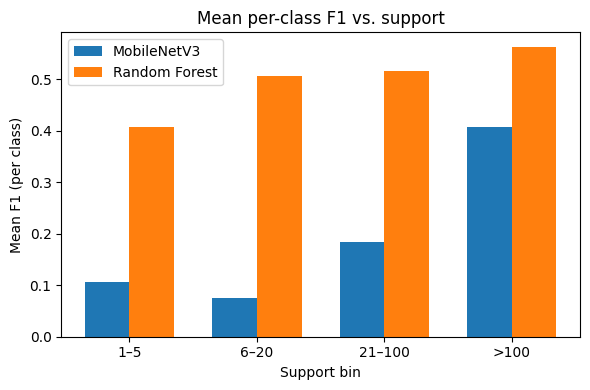

In [15]:
# Generate plots for error analysis from the provided classification reports.
import re, pandas as pd, numpy as np, matplotlib.pyplot as plt
from textwrap import dedent

# -----------------------------
# Raw text blocks (as provided)
# -----------------------------
mobile_report = dedent(r"""
Classification Report (All Folds):
              precision    recall  f1-score   support

     1139490       0.00      0.00      0.00         2
     1192948       1.00      0.50      0.67         4
     1194042       0.00      0.00      0.00         3
      126247       0.00      0.00      0.00         6
     1346504       1.00      0.20      0.33         5
      134933       0.00      0.00      0.00         4
      135045       1.00      0.10      0.18        10
     1462711       0.00      0.00      0.00         3
     1462737       0.33      0.29      0.31         7
     1564122       0.22      0.33      0.27         6
       21038       0.00      0.00      0.00         2
       21116       0.00      0.00      0.00         2
       21211       0.24      0.64      0.35        76
       22333       0.67      0.68      0.67        47
       22973       0.57      0.32      0.41        53
       22976       0.43      0.23      0.30        44
       24272       0.00      0.00      0.00         6
       24292       0.00      0.00      0.00         3
       24322       0.00      0.00      0.00        13
       41663       0.07      0.01      0.02       108
       41778       0.00      0.00      0.00         2
       41970       0.00      0.00      0.00        15
       42007       0.00      0.00      0.00        19
       42087       0.00      0.00      0.00         2
       42113       0.00      0.00      0.00         2
       46010       0.00      0.00      0.00         5
       47067       0.00      0.00      0.00         2
      476537       0.00      0.00      0.00         2
      476538       0.00      0.00      0.00         5
       48124       0.27      0.20      0.23        20
       50186       0.12      0.03      0.05        30
      517119       0.37      0.43      0.40        58
      523060       1.00      0.25      0.40         4
      528041       0.00      0.00      0.00         2
       52884       0.18      0.12      0.15        33
      548639       0.50      0.80      0.62         5
      555086       0.40      0.08      0.13        25
      555142       0.00      0.00      0.00         6
      566513       1.00      0.04      0.08        23
       64862       0.00      0.00      0.00         2
       65336       0.00      0.00      0.00         6
       65344       0.00      0.00      0.00        16
       65349       0.29      0.12      0.17        16
       65373       0.27      0.09      0.14        32
       65419       0.00      0.00      0.00         3
       65448       0.37      0.76      0.50        82
       65547       0.00      0.00      0.00         7
       65962       0.33      0.10      0.15        21
       66016       0.00      0.00      0.00         2
       66531       0.00      0.00      0.00         2
       66578       0.00      0.00      0.00         2
       66893       0.00      0.00      0.00         5
       67082       0.00      0.00      0.00         2
       67252       0.00      0.00      0.00        14
      714022       1.00      0.20      0.33         5
      715170       0.41      0.65      0.50        17
      787625       0.00      0.00      0.00         7
       81930       0.00      0.00      0.00         2
      868458       0.67      0.50      0.57         4
      963335       0.50      0.20      0.29         5
     amakin1       0.37      0.20      0.26        89
      amekes       0.35      0.64      0.45       409
     ampkin1       0.00      0.00      0.00        28
      anhing       0.18      0.12      0.14        91
      babwar       0.53      0.53      0.53       167
     bafibi1       0.00      0.00      0.00        27
      banana       0.53      0.69      0.60       610
      baymac       0.36      0.59      0.45       149
      bbwduc       0.35      0.49      0.41       424
     bicwre1       0.54      0.41      0.47        93
      bkcdon       0.42      0.31      0.36       176
     bkmtou1       0.67      0.76      0.71       311
     blbgra1       0.57      0.67      0.62       380
     blbwre1       0.47      0.24      0.32       110
     blcant4       0.45      0.49      0.47       105
     blchaw1       0.00      0.00      0.00        54
     blcjay1       0.27      0.19      0.22       108
     blctit1       0.00      0.00      0.00        32
     blhpar1       0.35      0.36      0.36       230
      blkvul       0.20      0.19      0.19        70
     bobfly1       0.35      0.43      0.39       514
     bobher1       0.08      0.03      0.04        39
     brtpar1       0.21      0.05      0.09        74
     bubcur1       0.00      0.00      0.00        20
     bubwre1       0.51      0.50      0.51       379
     bucmot3       0.33      0.02      0.04        47
      bugtan       0.38      0.38      0.38       280
     butsal1       0.45      0.40      0.42       298
     cargra1       0.20      0.01      0.02        94
      cattyr       0.33      0.21      0.26       114
     chbant1       0.64      0.66      0.65       270
     chfmac1       0.32      0.40      0.36       139
     cinbec1       0.32      0.09      0.14        67
     cocher1       0.00      0.00      0.00        40
     cocwoo1       0.46      0.26      0.33       162
     colara1       0.33      0.02      0.03        57
     colcha1       0.29      0.28      0.28       145
      compau       0.45      0.77      0.57       808
     compot1       0.74      0.76      0.75       383
     cotfly1       0.41      0.33      0.37       260
     crbtan1       0.00      0.00      0.00        56
     crcwoo1       0.36      0.26      0.30       144
     crebob1       0.75      0.18      0.29        50
     cregua1       0.46      0.30      0.36        77
     creoro1       0.44      0.32      0.37       229
     eardov1       0.36      0.24      0.29       105
      fotfly       0.29      0.05      0.09        80
     gohman1       0.40      0.10      0.17       134
     grasal4       0.24      0.16      0.20        85
     grbhaw1       0.35      0.31      0.33       107
     greani1       0.58      0.23      0.33       127
      greegr       0.34      0.56      0.43       340
     greibi1       0.46      0.61      0.53       109
      grekis       0.50      0.59      0.54       990
     grepot1       0.33      0.10      0.16        67
     gretin1       0.56      0.83      0.67        83
      grnkin       0.32      0.11      0.16       132
     grysee1       0.00      0.00      0.00        25
      gybmar       0.37      0.29      0.33       164
     gycwor1       0.67      0.70      0.68       365
     labter1       0.44      0.54      0.49        67
     laufal1       0.70      0.70      0.70       467
      leagre       0.11      0.02      0.03       108
     linwoo1       0.35      0.38      0.37       330
     littin1       0.63      0.78      0.70       323
     mastit1       0.06      0.02      0.03       109
      neocor       0.13      0.18      0.15        90
     norscr1       0.00      0.00      0.00        14
     olipic1       0.53      0.21      0.30        38
      orcpar       0.27      0.50      0.35       218
     palhor2       0.31      0.23      0.26        66
     paltan1       0.38      0.15      0.21       224
     pavpig2       0.49      0.52      0.50       151
     piepuf1       0.42      0.27      0.33        55
     pirfly1       0.50      0.67      0.57       324
     piwtyr1       0.00      0.00      0.00        19
     plbwoo1       0.15      0.10      0.12       186
     plctan1       0.00      0.00      0.00         6
     plukit1       0.00      0.00      0.00        38
     purgal2       0.26      0.05      0.09       147
     ragmac1       0.32      0.49      0.39        89
     rebbla1       0.00      0.00      0.00        55
     recwoo1       0.12      0.01      0.02        90
     rinkin1       0.37      0.33      0.35       222
      roahaw       0.51      0.54      0.52       709
     rosspo1       0.00      0.00      0.00        34
     royfly1       0.40      0.15      0.22        40
      rtlhum       0.46      0.28      0.35       148
     rubsee1       0.67      0.14      0.24        70
     rufmot1       0.38      0.23      0.28        97
      rugdov       0.45      0.54      0.50       138
     rumfly1       0.45      0.29      0.35       236
     ruther1       0.06      0.01      0.02        80
     rutjac1       0.48      0.35      0.40       261
     rutpuf1       0.25      0.06      0.10        17
      saffin       0.51      0.52      0.52       419
     sahpar1       0.00      0.00      0.00        14
     savhaw1       0.62      0.28      0.38        54
     secfly1       0.42      0.30      0.35       158
     shghum1       1.00      0.07      0.12        15
     shtfly1       0.38      0.16      0.22        90
      smbani       0.50      0.56      0.53       287
      snoegr       0.24      0.09      0.13       108
     sobtyr1       0.49      0.46      0.48       478
     socfly1       0.39      0.39      0.39       543
      solsan       0.40      0.19      0.25       237
     soulap1       0.57      0.75      0.65       487
     spbwoo1       0.35      0.15      0.21        48
     speowl1       0.41      0.54      0.47       201
     spepar1       0.07      0.02      0.04        81
     srwswa1       0.34      0.32      0.33       112
     stbwoo2       0.47      0.52      0.49       210
     strcuc1       0.53      0.69      0.60       431
     strfly1       0.29      0.47      0.36       377
      strher       0.34      0.26      0.29       169
     strowl1       0.49      0.30      0.37       164
     tbsfin1       0.25      0.40      0.31        40
     thbeup1       0.38      0.15      0.22       153
     thlsch3       0.46      0.53      0.49        97
      trokin       0.46      0.56      0.50       787
      tropar       0.55      0.54      0.55       397
      trsowl       0.52      0.60      0.55       470
      turvul       0.00      0.00      0.00        11
      verfly       0.33      0.01      0.03        69
     watjac1       0.44      0.35      0.39       133
     wbwwre1       0.43      0.47      0.45       499
     whbant1       0.62      0.65      0.64       104
     whbman1       0.27      0.53      0.36       246
     whfant1       0.41      0.59      0.48       126
     whmtyr1       0.00      0.00      0.00        34
      whtdov       0.64      0.73      0.68       572
     whttro1       0.50      0.40      0.44        75
     whwswa1       0.50      0.02      0.04        50
      woosto       0.00      0.00      0.00        27
      y00678       0.21      0.25      0.23       169
     yebela1       0.49      0.47      0.48       267
     yebfly1       0.43      0.38      0.40       188
     yebsee1       0.48      0.59      0.53       185
     yecspi2       0.43      0.45      0.44       235
     yectyr1       0.33      0.15      0.21        97
     yehbla2       0.00      0.00      0.00        79
     yehcar1       0.34      0.14      0.20       238
     yelori1       0.25      0.03      0.06        60
     yeofly1       0.41      0.64      0.50       525
     yercac1       0.25      0.14      0.18       302
      ywcpar       0.43      0.51      0.47       142

    accuracy                           0.45     28564
   macro avg       0.31      0.25      0.26     28564
weighted avg       0.43      0.45      0.42     28564


Overall Validation AUC (macro): 0.9316
""")

rf_report = dedent(r"""
Final Test Performance:
Accuracy: 0.5521633747614872
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.60      0.43      0.50         7
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       1.00      0.60      0.75         5
           5       1.00      0.75      0.86         4
           6       0.88      0.93      0.90        30
           7       0.50      0.33      0.40         6
           8       0.50      0.92      0.65        12
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         5
          12       0.69      0.33      0.45        27
          13       1.00      0.30      0.46        10
          14       0.85      0.39      0.54        28
          15       0.50      0.25      0.33        16
          16       0.00      0.00      0.00         3
          17       1.00      0.50      0.67         2
          18       1.00      0.64      0.78        11
          19       0.66      0.42      0.52        78
          20       1.00      0.25      0.40         4
          21       1.00      0.20      0.33         5
          22       1.00      0.20      0.33        10
          23       0.00      0.00      0.00         0
          25       0.75      1.00      0.86         3
          26       0.00      0.00      0.00         1
          27       1.00      0.40      0.57         5
          28       0.00      0.00      0.00         1
          29       0.88      0.78      0.83        49
          30       0.85      0.72      0.78        61
          31       0.86      0.29      0.43        21
          32       0.00      0.00      0.00         1
          33       0.50      0.33      0.40         3
          34       0.83      0.58      0.68        65
          35       0.00      0.00      0.00         1
          36       0.93      0.65      0.76        20
          37       0.00      0.00      0.00         1
          38       0.82      0.69      0.75        13
          39       1.00      0.90      0.95        10
          40       1.00      0.33      0.50         3
          41       1.00      0.56      0.71         9
          42       1.00      0.25      0.40         4
          43       1.00      0.20      0.33        10
          44       0.00      0.00      0.00         1
          45       0.62      0.40      0.49        25
          46       1.00      0.33      0.50         3
          47       0.00      0.00      0.00         5
          48       0.00      0.00      0.00         0
          49       1.00      1.00      1.00         1
          50       0.00      0.00      0.00         2
          51       1.00      1.00      1.00         1
          52       1.00      1.00      1.00         1
          53       1.00      0.63      0.77        19
          54       0.83      1.00      0.91         5
          55       0.40      0.62      0.48        13
          56       0.00      0.00      0.00         2
          58       0.00      0.00      0.00         1
          59       0.50      0.40      0.44         5
          60       0.62      0.19      0.29        26
          61       0.57      0.56      0.56       209
          62       0.67      0.17      0.27        12
          63       0.75      0.30      0.43        40
          64       0.80      0.61      0.69       162
          65       0.80      0.40      0.53        10
          66       0.49      0.83      0.62       462
          67       0.45      0.36      0.40        94
          68       0.63      0.43      0.51       162
          69       0.65      0.32      0.43        53
          70       0.62      0.56      0.59       126
          71       0.60      0.74      0.66       232
          72       0.65      0.73      0.69       288
          73       0.78      0.61      0.68       125
          74       0.94      0.30      0.45        57
          75       0.70      0.25      0.37        28
          76       0.67      0.49      0.57       116
          77       1.00      0.25      0.40        16
          78       0.54      0.35      0.43        82
          79       0.73      0.41      0.53        46
          80       0.43      0.50      0.46       326
          81       0.50      0.13      0.21        15
          82       0.86      0.40      0.55        45
          83       1.00      0.19      0.32        16
          84       0.55      0.52      0.54       267
          85       0.93      0.60      0.73        47
          86       0.50      0.34      0.41       169
          87       0.66      0.51      0.58       221
          88       0.74      0.38      0.50        45
          89       0.69      0.51      0.58        97
          90       0.63      0.70      0.66       230
          91       0.62      0.43      0.50        87
          92       0.59      0.27      0.37        37
          93       1.00      0.79      0.88        14
          94       0.72      0.53      0.61       131
          95       0.81      0.35      0.49        37
          96       0.65      0.65      0.65       164
          97       0.45      0.80      0.57       614
          98       0.84      0.68      0.75       252
          99       0.49      0.34      0.40       101
         100       0.83      0.37      0.51        27
         101       0.71      0.62      0.66       133
         102       0.73      0.58      0.64        33
         103       0.89      0.58      0.70        59
         104       0.59      0.42      0.49       180
         105       0.74      0.40      0.52        58
         106       1.00      0.29      0.45        51
         107       0.78      0.48      0.59       117
         108       0.83      0.27      0.41        55
         109       0.77      0.33      0.47        60
         110       0.87      0.59      0.70       110
         111       0.38      0.50      0.43       118
         112       0.81      0.43      0.56        61
         113       0.26      0.62      0.37       548
         114       0.91      0.64      0.75        45
         115       0.90      0.40      0.55        48
         116       0.74      0.46      0.56        68
         117       1.00      0.29      0.45        17
         118       0.74      0.25      0.38        67
         119       0.61      0.78      0.68       248
         120       0.83      0.22      0.34        23
         121       0.57      0.79      0.66       383
         122       0.76      0.37      0.50        51
         123       0.55      0.47      0.50       215
         124       0.66      0.64      0.65       270
         125       0.86      0.38      0.53        65
         126       0.83      0.40      0.54        47
         127       0.80      0.27      0.40        15
         128       0.86      0.50      0.63        24
         129       0.59      0.45      0.51       114
         130       0.56      0.22      0.31        23
         131       0.74      0.48      0.58       179
         132       0.83      0.26      0.40        92
         133       0.82      0.36      0.50        25
         134       0.62      0.46      0.53       256
         135       1.00      0.11      0.20         9
         136       0.82      0.44      0.58       135
         137       1.00      0.50      0.67         4
         138       0.88      0.25      0.39        28
         139       0.83      0.45      0.58        78
         140       0.78      0.31      0.44        45
         141       0.93      0.46      0.62        56
         142       0.64      0.23      0.33        31
         143       0.73      0.29      0.42        92
         144       0.29      0.62      0.40       584
         145       0.89      0.80      0.84        30
         146       1.00      0.44      0.62        18
         147       0.83      0.53      0.65       117
         148       0.85      0.39      0.53        59
         149       0.88      0.55      0.68        78
         150       0.79      0.41      0.54        73
         151       0.75      0.35      0.48       142
         152       0.97      0.61      0.75        56
         153       0.72      0.33      0.45       124
         154       1.00      0.22      0.36         9
         155       0.50      0.61      0.55       319
         156       1.00      0.33      0.50         6
         157       0.57      0.17      0.26        24
         158       0.67      0.37      0.48        75
         159       1.00      0.50      0.67        10
         160       0.90      0.35      0.51        54
         161       0.61      0.34      0.43       136
         162       0.71      0.29      0.41        42
         163       0.50      0.35      0.41       272
         164       0.44      0.52      0.48       377
         165       0.70      0.30      0.42        99
         166       0.45      0.35      0.40       175
         167       0.80      0.36      0.50        22
         168       0.83      0.84      0.83       298
         169       0.88      0.44      0.59        50
         170       0.76      0.42      0.54        53
         171       0.67      0.55      0.61       137
         172       0.65      0.58      0.61       279
         173       0.64      0.43      0.52       256
         174       0.51      0.38      0.43        53
         175       0.85      0.60      0.71       162
         176       0.89      0.35      0.50        23
         177       0.83      0.39      0.53       127
         178       0.83      0.64      0.72        91
         179       0.49      0.68      0.57       500
         180       0.61      0.57      0.59       327
         181       0.61      0.78      0.69       440
         182       1.00      0.11      0.20         9
         183       1.00      0.13      0.23        39
         184       0.58      0.15      0.24        46
         185       0.54      0.55      0.55       358
         186       0.78      0.37      0.50        84
         187       0.56      0.57      0.56       246
         188       0.62      0.44      0.51        98
         189       0.77      0.42      0.54        24
         190       0.49      0.75      0.59       562
         191       0.96      0.45      0.61        49
         192       0.89      0.47      0.62        34
         193       0.85      0.50      0.63        22
         194       0.80      0.32      0.46        74
         195       0.71      0.41      0.52       131
         196       0.71      0.46      0.56       129
         197       0.68      0.44      0.53       153
         198       0.61      0.57      0.59       190
         199       0.67      0.13      0.22        45
         200       0.91      0.57      0.70        56
         201       0.69      0.31      0.42       121
         202       0.83      0.48      0.61        42
         203       0.52      0.59      0.55       414
         204       0.36      0.67      0.47       403
         205       0.80      0.41      0.54       107

    accuracy                           0.55     19391
   macro avg       0.70      0.44      0.51     19391
weighted avg       0.62      0.55      0.55     19391
""")

# -----------------------------
# Helpers
# -----------------------------
def parse_cls_report(text):
    rows = []
    for line in text.splitlines():
        line = line.strip()
        m = re.match(r"^([A-Za-z0-9]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)$", line)
        if m:
            label, prec, rec, f1, supp = m.groups()
            rows.append({"label": label, "precision": float(prec), "recall": float(rec),
                         "f1": float(f1), "support": int(supp)})
    return pd.DataFrame(rows)

df_m = parse_cls_report(mobile_report)
df_r = parse_cls_report(rf_report)

# Summaries by support bins
def by_support_bins(df):
    bins = pd.cut(df["support"], bins=[0,5,20,100,100000], labels=["1–5","6–20","21–100",">100"], include_lowest=True, right=True)
    g = df.groupby(bins).agg(mean_f1=("f1","mean"),
                             mean_rec=("recall","mean"),
                             zero_rec=("recall", lambda s: (s==0).sum()),
                             zero_f1=("f1", lambda s: (s==0).sum()),
                             n=("f1","size"))
    g["zero_rec_pct"] = g["zero_rec"]/g["n"]
    g["zero_f1_pct"] = g["zero_f1"]/g["n"]
    return g

g_m = by_support_bins(df_m)
g_r = by_support_bins(df_r)

# 1) Mean F1 by support bin (bar, paired)
plt.figure(figsize=(6,4))
bins = g_m.index.astype(str)
x = np.arange(len(bins))
w = 0.35
plt.bar(x - w/2, g_m["mean_f1"].values, w, label="MobileNetV3")
plt.bar(x + w/2, g_r["mean_f1"].values, w, label="Random Forest")
plt.ylabel("Mean F1 (per class)")
plt.xlabel("Support bin")
plt.title("Mean per-class F1 vs. support")
plt.xticks(x, bins)
plt.legend()
plt.tight_layout()
plot_mean_f1 = "/mnt/data/mean_f1_by_support_bin.png"
plt.savefig(plot_mean_f1, dpi=200)
plt.close()

# 2) Zero-recall fraction by support bin (line)
plt.figure(figsize=(6,4))
plt.plot(bins, g_m["zero_rec_pct"].values, marker='o', label="MobileNetV3")
plt.plot(bins, g_r["zero_rec_pct"].values, marker='o', label="Random Forest")
plt.ylabel("Fraction with recall=0")
plt.xlabel("Support bin")
plt.title("Zero-recall rate vs. support")
plt.legend()
plt.tight_layout()
plot_zero_recall = "/mnt/data/zero_recall_rate_by_bin.png"
plt.savefig(plot_zero_recall, dpi=200)
plt.close()

# 3) Scatter: support vs F1, each model
def scatter(df, title, out):
    plt.figure(figsize=(6,4))
    plt.scatter(df["support"], df["f1"], alpha=0.5)
    plt.xscale("log")
    plt.xlabel("Class support (log scale)")
    plt.ylabel("F1 (per class)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.close()

scatter(df_m, "MobileNetV3: per-class F1 vs. support", "/mnt/data/scatter_support_f1_mobilenet.png")
scatter(df_r, "Random Forest: per-class F1 vs. support", "/mnt/data/scatter_support_f1_rf.png")

# 4) Top-5 supported classes with F1 (bar) for MobileNetV3
def top_bottom_plots(df, model_name, prefix):
    top5 = df.sort_values("support", ascending=False).head(5)
    bot5 = df.sort_values("support", ascending=True).head(5)
    # Top-5
    plt.figure(figsize=(6,4))
    plt.bar(top5["label"].astype(str), top5["f1"])
    plt.ylabel("F1")
    plt.xlabel("Label (top-5 by support)")
    plt.title(f"{model_name}: F1 on Top-5 Supported Classes")
    plt.tight_layout()
    top_path = f"/mnt/data/{prefix}_top5_support_f1.png"
    plt.savefig(top_path, dpi=200)
    plt.close()
    # Bottom-5
    plt.figure(figsize=(6,4))
    plt.bar(bot5["label"].astype(str), bot5["f1"])
    plt.ylabel("F1")
    plt.xlabel("Label (bottom-5 by support)")
    plt.title(f"{model_name}: F1 on Bottom-5 Supported Classes")
    plt.tight_layout()
    bot_path = f"/mnt/data/{prefix}_bottom5_support_f1.png"
    plt.savefig(bot_path, dpi=200)
    plt.close()
    return top_path, bot_path, top5, bot5

mn_top, mn_bot, mn_top5_df, mn_bot5_df = top_bottom_plots(df_m, "MobileNetV3", "mobilenet")
rf_top, rf_bot, rf_top5_df, rf_bot5_df = top_bottom_plots(df_r, "Random Forest", "rf")

# Save CSV summaries
summary_csv = "/mnt/data/error_analysis_support_bins_summary.csv"
pd.concat({"MobileNetV3": g_m, "RandomForest": g_r}, axis=1).to_csv(summary_csv)

# Also save the top/bottom tables
mn_top5_df.to_csv("/mnt/data/mobilenet_top5_support.csv", index=False)
mn_bot5_df.to_csv("/mnt/data/mobilenet_bottom5_support.csv", index=False)
rf_top5_df.to_csv("/mnt/data/rf_top5_support.csv", index=False)
rf_bot5_df.to_csv("/mnt/data/rf_bottom5_support.csv", index=False)

{
 "plot_mean_f1": plot_mean_f1,
 "plot_zero_recall": plot_zero_recall,
 "scatter_mobilenet": "/mnt/data/scatter_support_f1_mobilenet.png",
 "scatter_rf": "/mnt/data/scatter_support_f1_rf.png",
 "mn_top": mn_top, "mn_bot": mn_bot,
 "rf_top": rf_top, "rf_bot": rf_bot,
 "summary_csv": summary_csv,
 "mn_top5_csv": "/mnt/data/mobilenet_top5_support.csv",
 "mn_bot5_csv": "/mnt/data/mobilenet_bottom5_support.csv",
 "rf_top5_csv": "/mnt/data/rf_top5_support.csv",
 "rf_bot5_csv": "/mnt/data/rf_bottom5_support.csv",
}
